# Trabajo práctico integrador - Grupo 4

El comitente posee un sistema desarrollado sobre una web, con un carrusel que muestra a los usuarios juegos que pueden interesarle al cliente. Actualmente, los juegos mostrados al cliente se eligen de manera aleatoria.
<br><br>
Este es el proceso de minería de datos para obtener el sistema recomendador que reemplazara las recomendaciones aleatorias que actualmente tiene el sistema. Para la realización del proceso, utilizaremos la metodología CRISP-DM. Seguiremos sus fases y actividades genéricas siempre que consideremos que sean requeridas, y en caso de saltear alguna justificaremos por qué no la incluimos.

## Fase 1 - Entendimiento del negocio

Nuestro objetivo en esta fase es entender el problema de negocio y traducirlo a un problema de minería de datos.

### Actividad 1.1: Determinar objetivos de negocio

El objetivo de negocio es aumentar las ganancias por ventas de videojuegos en un 10% para el año 2026 (comparandolo con las ventas del 2025).

### Actividad 1.2: Evaluar la situacion actual

El caso a tratar es sobre una plataforma virtual de venta de videojuegos. Contamos con la siguiente información del sistema:
* Hay un total de 100 juegos en venta.
* El sistema actual de recomendación muestra artículos aleatorios.
* No se cuenta con una base de datos (no hay usuarios, ni preferencias, ni ítems).
<br><br>

Y como supuestos del problema:
* No se agregarán nuevos ítems al carrusel.
* Cada usuario suele comprar entre 7 y 8 con una varianza de 10 juegos.

### Actividad: 1.3 Determinar los objetivos de la minería de datos

El objetivo de la minería de datos es crear un sistema recomendador capaz de recomendar k videojuegos a un usuario determinado, de tal forma que las recomendaciones cumplan con los siguientes requisitos:
* Novedad: El sistema recomendador no debe recomendar videojuegos ya puntuados por el usuario.
* Diversidad: La diversidad de las recomendaciones generadas por el sistema recomendador no deberá ser inferior en más de un 20% a la diversidad obtenida mediante un sistema de recomendaciones aleatorias.
* Serendipia: Al menos un 15% de los artículos recomendados deben ser inesperados para el usuario.
* Relevancia: Al menos un 60% de los artículos recomendados deberán ser relevantes para el usuario.

Además de recomendar k videojuegos a un usuario cumpliendo los requisitos anteriores, el sistema recomendador debe ser capaz de generar esas k recomendaciones en un tiempo menor a un segundo.

### Actividad: 1.4: Elaborar un plan de proyecto

Hasta ahora planteamos los objetivos de negocio (lo que quieren los stakeholders), analizamos la situación actual y determinamos qué queremos lograr en el proceso de minería de datos. A partir de ahora, el plan es el siguiente:
1. **Entender los datos:** Coincide con la fase 2 de CRISP-DM. Buscamos:
    * Familiarizarnos con el dataset.
    * Analizar cada atributo (tipo, semántica, rango).
    * Detectar anomalías
    * Verificar la calidad de los datos.
2. **Preparar los datos para el modelo:** Coincide con la fase 3 de CRISP-DM. Buscamos:
    * Asegurar la calidad de los datos.
    * Preparar esos datos para el modelado.
3. **Modelar el sistema recomendador:** Coincide con la fase 4 de CRISP-DM. Buscamos:
    * Seleccionar la técnica de modelado adecuada basándonos en la información obtenida en todo el proceso anterior.
    * Definir métricas de evaluación de los sistemas recomendadores candidatos.
    * Construir los sistemas recomendadores.
    * Evaluarlos según los criterios definidos anteriormente.
    * Elegir el sistema recomendador que más se ajuste a esos criterios.
4. **Evaluar el modelo:** Coincide con la fase 5 de CRISP-DM. Tenemos que verificar que el sistema recomendador elegido cumpla con los objetivos de la minería de datos planteados en la fase 1.
5. **Desplegar el modelo:** Coincide con la fase 6 de CRISP-DM. Consiste en definir cómo implementaremos el sistema recomendador y definir un plan de seguimiento del mismo.
<br>
<br>

Cabe aclarar que en todo momento tendremos en cuenta que CRISP-DM es una metodología iterativa, y por ende contempla (y casi que exige) que no se siga una secuencia lineal entre fases. A lo largo del proceso volveremos hacia atrás entre fases y actividades siempre que lo consideremos necesario. El plan solo representa una secuencia ideal de trabajo, que puede ser ajustada o modificada durante el desarrollo del proyecto.

## Fase 2 - Entendimiento de los datos

El objetivo principal de esta fase es familiarizarnos con los datos. Antes de empezar con este proceso, es necesario cargar todas las librerías que utilizaremos a lo largo del trabajo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import seaborn as sns
import statistics

### Actividad 2.1: Recolección inicial de los de datos

Los datos de los 100 juegos se encuentran en el archivo subido a GitHub database/games.csv, así que procedemos a cargar este archivo en nuestro Jupyter y verificamos si se cargó correctamente

In [2]:
df = pd.read_csv(r"../database/games.csv")
df

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher
0,1300638463,Astro Bot,2024-09-06,E10+,Platformer,When the PS5 mothership is attacked by ASTRO’s...,PlayStation 5,94.0,136,Universal acclaim,91,5575,Universal acclaim,94,Team Asobi,Sony Interactive Entertainment
1,1300501848,Baldur's Gate 3,2023-08-03,M,RPG,"An ancient evil has returned to Baldur's Gate,...","PC,PlayStation 5,Xbox Series X",96.0,112,Universal acclaim,92,20175,Universal acclaim,"96,96,99",Larian Studios Games,Larian Studios Games
2,1300044321,Battlefield 3,2011-10-25,M,"Shooter, Strategy","As bullets whiz by, walls crumble, and explosi...","PC,Xbox 360,PlayStation 3",89.0,61,Generally favorable,77,6240,Generally favorable,"89,84,85",EA DICE,Electronic Arts
3,1300022724,BioShock,2007-08-21,M,Shooter,"Going beyond ""run and gun corridors,"" ""monster...","PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)",96.0,88,Universal acclaim,88,4067,Generally favorable,"96,96,94,68","Irrational Games,2K Marin","2K Games,Spike"
4,1300287014,Bloodborne,2015-03-24,M,"Action, RPG",Bloodborne is an action RPG in which you hunt ...,PlayStation 4,92.0,100,Universal acclaim,89,14147,Generally favorable,92,From Software,"SCEA,Sony Interactive Entertainment,SCEI,SCEE,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1300108757,Trials Evolution,2012-04-18,E10+,"Simulation, Racing",The follow-up to Trials HD brings the bike-rac...,Xbox 360,90.0,77,Universal acclaim,80,311,Generally favorable,90,"RedLynx,Ubisoft",Microsoft Game Studios
96,1300041127,Uncharted 2: Among Thieves,2009-10-13,T,"Action, Adventure",Fortune hunter Nathan Drake returns in Unchart...,PlayStation 3,96.0,105,Universal acclaim,89,8049,Generally favorable,96,Naughty Dog,"SCEA,SCEI,SCEE,SCE Australia"
97,1300223143,Uncharted 4: A Thief's End,2016-05-10,T,"Action, Adventure","Set 3 years after the events of Uncharted 3, N...",PlayStation 4,93.0,113,Universal acclaim,87,17189,Generally favorable,93,Naughty Dog,"Sony Interactive Entertainment,SCEE,SCE Australia"
98,1300032946,World of Warcraft: Wrath of the Lich King,2008-11-13,T,"RPG, Puzzle/Horror","Players last visited Northrend in ""Warcraft II...",PC,91.0,47,Universal acclaim,82,1492,Generally favorable,91,Blizzard Entertainment,Blizzard Entertainment


Estos datos fueron proporcionados por el stakeholder, el archivo se subió GitHub y ahora lo cargamos en el Jupyter. Está listo para ser tratado en el proceso de minería de datos.

### Actividad 2.2: Descripción de los datos

Necesitamos realizar una descripción detallada de los datos y de sus particularidades.

#### Instancia 2.2.1: Tamaño del dataset, atributos y valores nulos

Utilizamos .info y .info().sum() para conocer la informacion de las columnas del data frame y corroborar que sí tiene 100 juegos en total.

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   100 non-null    int64  
 1   title                100 non-null    str    
 2   releaseDate          100 non-null    str    
 3   rating               95 non-null     str    
 4   genres               100 non-null    str    
 5   description          100 non-null    str    
 6   platforms            100 non-null    str    
 7   metascore            100 non-null    float64
 8   metascore_count      100 non-null    int64  
 9   metascore_sentiment  100 non-null    str    
 10  userscore            100 non-null    int64  
 11  userscore_count      100 non-null    int64  
 12  userscore_sentiment  100 non-null    str    
 13  platform_metascores  100 non-null    str    
 14  developer            100 non-null    str    
 15  publisher            100 non-null    str    
dtypes:

id                     0
title                  0
releaseDate            0
rating                 5
genres                 0
description            0
platforms              0
metascore              0
metascore_count        0
metascore_sentiment    0
userscore              0
userscore_count        0
userscore_sentiment    0
platform_metascores    0
developer              0
publisher              0
dtype: int64

Efectivamente, el dataset contiene 100 elementos. Además, podemos ver que en rating se encuentran 5 datos nulos en la columna "rating", mientras que el resto de columnas no tienen valores nulos. Dejamos pendiente el análisis de estos valores nulos para la actividad 2.4 (verificación de la calidad de los datos).
<br>

Tambien logramos conocer cada uno de los atributos del dataset: <br>
* id
* title
* releaseDate
* rating
* genres
* description
* platforms
* metascore
* metascore_count
* metascore_sentiment
* userscore
* userscore_count
* userscore_sentiment
* platform_metascores
* developer
* publisher

#### Instancia 2.2.2: Análisis del atributo "rating"

Ahora, queremos describir c/atributo y entenderlo. Queremos conocer:
* Su tipo
* Su rango de valores
* Su semántica asociada
* Tener una idea de su distribución estadística

Y ya que estabamos hablando del atributo "rating", empezaremos con este.

In [5]:
print(df["rating"].dtype)
df["rating"].value_counts()

str


rating
M       35
E       28
T       23
E10+     9
Name: count, dtype: int64

Los valores posibles son:
* M
* T
* E10+
* E

Inicialmente pensabamos que estaba relacionado a la puntuación del juego, pero no tiene mucho sentido con los valores vistos. Investigando qué significan estas letras, encontramos que corresponden al sistema de clasificación por edades de ESRB. Estas clasificaciones se muestran en la página oficial de ESRB: [Guía oficial de clasificaciones ESRB](https://www.esrb.org/ratings-guide/)
<br>
<br>

Significado de c/valor (semántica):
* M (Mature) → 17+ años. Contenido para adultos, puede contener violencia fuerte, lenguaje fuerte, etc.
* T (Teen) → 13+ años. Contenido para adolescentes o adultos, puede haber violencia moderada, lenguaje leve o temas sugestivos.
* E10+ (Everyone 10+) → 10+ años. Algo más de acción o violencia caricaturesca.
* E (Everyone) → Apto para todo público.
<br>
<br>

Este atributo es de tipo ordinal. Sus valores representan categorías de clasificación etaria de los videojuegos. Las categorías no son cuantitativas, pero poseen un orden natural según la edad del usuario. Se trata de categorías, como un atributo nominal, pero al tener un orden, es un atributo ordinal. Además, como solo puede tener un solo valor, es univaluado.
<br>
<br>

Al ser un atributo ordinal, el dominio de "rating" serían las categorías de ESRB ya mencionadas, que ordenados de menor a mayor serían:
1. E (28)
2. E10+ (9)
3. T (23)
4. M (35)

En consecuencia, el rango ordinal del atributo va desde E (menor restricción) hasta M (mayor restricción).
<br>
<br>

En cuánto a la distribución estadística:
* Estamos ante una distribución asimétrica con sesgo negativo. Los juegos de la parte derecha de la clasificación, los superiores, M y T, son muchos más que los de la izquierda, E10+ y E, por lo que está sesgada hacia la izquierda (sesgo negativo).
* La moda es M, los juegos para adultos, con un total de 35 juegos.
* Tenemos 3 clases predominantes, con cantidades bastante similares (E(28), T(23) y M(35)), y una clase con pocos elementos (9). Al ser E10+ una categoría intermedia con baja frecuencia, nos indica que esta clase es la que nos genera asimetría en la distribución, pero en general, los juegos están distribuidos entre todas las categorías etarias.

**Conclusiones del atributo "rating":**
* Tipo: Ordinal univaluado.
* Semántica: Clasificación etaria del juego formato ESRB, E: Todo público, E10+: Mayores de 10, T: Adolescentes mayores de 13, M: Mayores de 17
* Dominio (ordenado): [E, E10+, T, M].
* Distribución estadística: Distribución asimétrica con sesgo negativo, que podría ser simétrica simplificando las categorías E10+ y E en una sola E.

#### Instancia 2.2.3: Análisis del atributo "releaseDate"

Traduciendolo al español, sabemos que la semántica de este atributo es la fecha de lanzamiento del juego (salvo que durante su descripción descubramos algo diferente a esto, mantendremos ésta interpretación). Veamos algunos valores y observemos cómo está codificado el atributo.

In [4]:
df["releaseDate"].dtype
df["releaseDate"].head(5)

0    2024-09-06
1    2023-08-03
2    2011-10-25
3    2007-08-21
4    2015-03-24
Name: releaseDate, dtype: str

Las fechas están en formato string, pero el tipo de atributo es numérico intervalado-discreto. Es numérico porque es un atributo cuantitativo, es discreto porque entre dos valores no siempre hay un valor (por ejemplo, dos fechas correspondientes a días consecutivos), y es intervalado porque los valores están en una escala ordenada donde las diferencias entre valores tienen significado (podemos calcular cuántos días hay entre dos fechas). Además, es univaluado, pues solo puede tomar un solo valor.
<br>
<br>

Para conocer el rango, pasaremos las fechas codificadas como string a formato date, verificamos que no se haya perdido ninguna fecha por el camino y miramos los máximos y mínimos

In [5]:
df_datesfixed = df.copy()
df_datesfixed["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
print(len(df_datesfixed))
df_datesfixed["releaseDate"].agg(["min","max"])

100


min   2001-07-09
max   2025-09-04
Name: releaseDate, dtype: datetime64[us]

El rango de fechas entonces es [2001-07-09, 2025-19-04].
<br>
<br>

Para darnos una idea de la distribución estadística, utilizaremos descriptores estadísticos. Para ello, nos conviene discretizar las fechas en años, y ahí calculamos la moda, la mediana y el promedio:

In [6]:
df_dates_as_year = df_datesfixed.copy()
df_dates_as_year["releaseDate"] = pd.to_datetime(df_datesfixed["releaseDate"], errors="coerce").dt.year

# Verifico que el cambio se haya hecho correctamente
print(len(df_dates_as_year))
print("Min:", df_dates_as_year["releaseDate"].min())
print("Max:", df_dates_as_year["releaseDate"].max())

# Calculo el promedio, mediana y moda
promedio = df_dates_as_year["releaseDate"].mean()
mediana = df_dates_as_year["releaseDate"].median()
moda = df_dates_as_year["releaseDate"].mode()[0]
cantidad = df_dates_as_year["releaseDate"].value_counts().iloc[0]

print(f"Promedio: {promedio}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}, cantidad de juegos en ese año: {cantidad}")

100
Min: 2001
Max: 2025
Promedio: 2014.06
Mediana: 2014.5
Moda: 2010, cantidad de juegos en ese año: 7


Sobre la distribución estadística:
* La distribución parece bastante equilibrada dentro del rango analizado. Esta apenas sesgada hacia la izquierda, mucho menos de lo que se esperaba. Podíamos pensar que, como en los últimos años se han lanzado más juegos que nunca, el promedio, la mediana y la moda iban a estar más sesgados hacia la izquierda, y no es el caso. Aún así, como Promedio (2014.06) < Mediana (2014.5), podemos afirmar que tiene un leve sesgo negativo (hacia la izquierda).
* Podíamos pensar que el juego del 2001 era una "anomalía", pero en cierto modo, que el sesgo hacia los últimos años no sea excesivo, nos discipa de dudas (por el momento, veremos más adelante).
* La moda es el 2010, es el año con más videojuegos lanzados en el dataset.

**Conclusiones del atributo "releaseDate":**
* Tipo: Numérico intervalado-discreto univaluado.
* Semántica: Fecha de lanzamiento del juego.
* Rango: [2001-07-09, 2025-19-04].
* Distribución estadística: Leve sesgo hacia la izquierda (sesgo negativo).

#### Instancia 2.2.4: Semántica y tipo de los atributos "metascore", "metascore_count", "metascore_sentiment", "userscore", "userscore_count", "userscore_sentiment"
Todos estos atributos son similares y están relacionados entre sí. Enseguida veremos porque. Veamos los valores que contienen estos atributos.

In [7]:
df[["metascore","metascore_count","metascore_sentiment","userscore", "userscore_count","userscore_sentiment"]].head(10)

,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment
0,94.0,136,Universal acclaim,91,5575,Universal acclaim
1,96.0,112,Universal acclaim,92,20175,Universal acclaim
2,89.0,61,Generally favorable,77,6240,Generally favorable
3,96.0,88,Universal acclaim,88,4067,Generally favorable
4,92.0,100,Universal acclaim,89,14147,Generally favorable
5,94.0,76,Universal acclaim,87,331,Generally favorable
6,87.0,89,Generally favorable,72,2669,Mixed or average
7,83.0,72,Generally favorable,43,2192,Generally unfavorable
8,82.0,63,Generally favorable,62,2095,Mixed or average
9,77.0,87,Generally favorable,44,2134,Generally unfavorable


Semánticamente, "metascore" es el puntaje promedio que los críticos asignaron al juego en cuestión, "metascore_count" es la cantidad de puntajes tomados para calcular ese promedio, y "metascore_sentiment" es la traducción cualitativa del puntaje numérico que vimos de los criticos, básicamente agrupa los puntajes en rangos y los etiqueta. El rango específico para cada valor de "metascore_sentiment" lo veremos en la actividad 2.3 (exploración de los datos), cuando comparemos "metascore" con "metascore_sentiment".
<br>
<br>

Paralelamente, sucede lo mismo con "userscore", "userscore_count" y "userscore_sentiment". "userscore" se refiere al puntaje promedio de los usuarios, "userscore_count" es la cantidad de puntajes tomados para calcular ese promedio, y "userscore_sentiment" es un adjetivo descriptivo de ese puntaje.
<br>
<br>

Tanto "metascore" como "metascore_count", "userscore" y "userscore_count" son atributos numéricos, pues contienen números que representan cantidades. Son numéricos discretos pues los valores son siempre enteros, y son proporcionados porque no pueden tomar valores negativos. Todos ellos son univaluados, pues solo pueden tomar un valor.
<br>
<br>

Por otro lado, "userscore_sentiment" y "metascore_sentiment" son atributos ordinales, pues son categorías que tienen un orden jerárquico pero no podemos establecer una distancia cuantitativa entre características. Numéricamente si podríamos calcularla porque tenemos el "metascore" o el "userscore", pero si tendríamos solo el sentimiento, verdaderamente no sabemos cuánta diferencia hay entre "Generally favorable" y "Mixed or average". Por eso es ordinal. A su vez es univaluado, solo puede tener un valor a la vez.

#### Instancia 2.2.5: Rango y distribución estadística de los atributos "userscore_sentiment" y "metascore_sentiment"

Ya conociendo la semántica de los 6 atributos anteriores, tenemos que ver los rangos/dominios de c/uno. Empecemos con los rangos de "userscore_sentiment" y "metascore_sentiment"

In [8]:
sentimientos_metascore = df["metascore_sentiment"].unique().tolist()
sentimientos_userscore = df["userscore_sentiment"].unique().tolist()

print("Valores posibles en metascore_sentiment:")
for sentimiento in sentimientos_metascore:
    print(f"• {sentimiento}")

print("\nValores posibles en userscore_sentiment:")
for sentimiento in sentimientos_userscore:
    print(f"• {sentimiento}")

Valores posibles en metascore_sentiment:
• Universal acclaim
• Generally favorable

Valores posibles en userscore_sentiment:
• Universal acclaim
• Generally favorable
• Mixed or average
• Generally unfavorable


El dominio de "metascore_sentiment", ordenado de mayor a menor, sería:
* Universal acclaim.
* Generally favorable.
<br>
<br>

Mientras que el dominio de "userscore_sentiment", ordenado de mayor a menor, sería:
* Universal acclaim.
* Generally favorable.
* Mixed or average.
* Generally unfavorable.
<br>
<br>

Podemos ver ya con el sentimiento de la puntuación, que los usuarios suelen poner puntuaciones más bajas a los juegos que los críticos. Seguramente podremos corroborar esto con los descriptores básicos de "userscore" y "metascore". Pero primero veamos la distribución estadística de estas categorías.

In [9]:
porcentajes_metascore = df["metascore_sentiment"].value_counts(normalize=True) * 100
print("Porcentaje de aparición en metascore_sentiment")
for sentimiento, porcentaje in porcentajes_metascore.items():
    print(f"• {sentimiento}: {porcentaje:.2f}%")
    
print('')
porcentajes_userscore = df["userscore_sentiment"].value_counts(normalize=True) * 100
print("Porcentaje de aparición en userscore_sentiment")
for sentimiento, porcentaje in porcentajes_userscore.items():
    print(f"• {sentimiento}: {porcentaje:.2f}%")

Porcentaje de aparición en metascore_sentiment
• Universal acclaim: 68.00%
• Generally favorable: 32.00%

Porcentaje de aparición en userscore_sentiment
• Generally favorable: 76.00%
• Universal acclaim: 13.00%
• Mixed or average: 7.00%
• Generally unfavorable: 4.00%


Distribución estadística "userscore_sentiment":
* Universal acclaim: 13.00%
* Generally favorable: 76.00%
* Mixed or average: 7.00%
* Generally unfavorable: 4.00%
<br>
<br>

Distribución estadística "metascore_sentiment":
* Universal acclaim: 68.00%
* Generally favorable: 32.00%
<br>
<br>

Con estas distribuciones podemos ver que "metascore_sentiment" no nos dice mucho sobre el juego. Parece que a los críticos les gustan todos los juegos del dataset, y aclaman a una gran parte de ellos. Los usuarios parece que tienen puntajes más realistas, o por lo menos más distribuidos, aunque siguen percibiendo los juegos positivamente en su gran mayoría. 
<br>
<br>

Respecto a "userscore_sentiment", es una distribución asimétrica sesgada hacia la izquierda, puesto que los valores están concentrados en la derecha de la distribución, ya sea aclamados por los usuarios o simplemente con opiniones positivas.

**Conclusiones del atributo "metascore_sentiment":**
* Tipo: Ordinal univaluado.
* Semántica: Etiqueta cualitativa que resume el consenso de la crítica especializada sobre la calidad del juego.
* Dominio: [Generally favorable, Universal acclaim]
* Distribución estadística: Muchos de ellos son aclamados universalmente (68%) por la crítica y una porción considerable (32%) son valorados positivamente pero no aclamados.

**Conclusiones del atributo "userscore_sentiment":**
* Tipo: Ordinal univaluado
* Semántica: Etiqueta cualitativa que resume el consenso y la percepción de la comunidad de jugadores sobre el juego.
* Dominio: [Universal acclaim, Generally favorable, Mixed or average, Generally unfavorable]
* Distribución estadística: Sesgada negativamente.

#### Instancia 2.2.6: Rango y distribución estadística de los atributos "metascore_count" y "userscore_count"

Repasando un poco su semántica, estos atributos cuentan la cantidad de críticos ("metascore_count") y "usuarios" ("userscore_count") que puntuaron el juego y componen el puntaje general del mismo ("metascore" para "metascore_count" y "userscore" para "userscore_count"). Ambos pueden actuar como un intervalo de confianza, a mayor cantidad de reseñas, más representativo y fiable es el puntaje promedio del juego. También pueden ser buenos indicadores de popularidad, ya que si un juego tiene tantas puntuaciones realizadas, es porque es conocido y muy jugado, independientemente de no tenga puntuación tan alta.
<br>
<br>

Ahora sí, vamos con el rango. Entendiendo la semántica, el dominio de valores serían los números enteros positivos, pero podemos acotar un poco ese rango observando los valores de nuestro dataset.

In [10]:
min_meta = df["metascore_count"].min()
max_meta = df["metascore_count"].max()

min_user = df["userscore_count"].min()
max_user = df["userscore_count"].max()

print("Atributo metascore_count")
print("Mínimo:", min_meta)
print("Máximo:", max_meta)

print('')
print("Atributo userscore_count")
print("Mínimo:", min_user)
print("Máximo:", max_user)

Atributo metascore_count
Mínimo: 34
Máximo: 150

Atributo userscore_count
Mínimo: 77
Máximo: 166719


Rango "metascore_count": [34, 150]
<br>
Rango "userscore_count": [77, 166719]
<br>

No podemos concluir demasiado a partir de estos rangos, solo podemos empezar a pensar que hay muchos más usuarios que puntúan los juegos respecto a los críticos que los puntúan, lo cuál es totalmente esperable. Confirmaremos esto mediante descriptores estadísticos.

In [11]:
media = df["metascore_count"].mean()
mediana = df["metascore_count"].median()
desviacion = df["metascore_count"].std()

print("Estadísticas de metascore_count")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

media = df["userscore_count"].mean()
mediana = df["userscore_count"].median()
desviacion = df["userscore_count"].std()

print('')
print("Estadísticas de userscore_count")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

Estadísticas de metascore_count
Media: 87.62
Mediana: 85.00
Desviación Estándar: 25.61

Estadísticas de userscore_count
Media: 6487.45
Mediana: 2568.00
Desviación Estándar: 17481.27


Descriptores estadísticos de "metascore_count":
* Media: 87.62
* Mediana: 85
* Desviacion Estandar: 25.61
<br>
<br>

Descriptores estadísticos de "userscore_count":
* Media: 6487.45
* Mediana: 2568.00
* Desviacion Estandar: 17481.27
<br>
<br>

Decidimos no utilizar la moda ya que no tiene mucho sentido teniendo tantos valores discretos posibles. Podríamos discretizar, pero creemos que con la media y la mediana alcanza. La varianza tampoco la incluimos dado a que no es tan interpretable como la desviación estándar.
<br>

Respecto a los valores hallados, se corrobora lo que esperabamos, la mediana y el promedio nos muestran que la mayoría de juegos son puntuados por muchos más usuarios que por críticos. En "metascore_count", la media y mediana son similares y están bastante centradas dentro del rango, lo que nos hace pensar más en una distribución simétrica. Pero también es cierto que Media (87.62) > Mediana (85) por lo que puede considerarse levemente sesgada hacia la derecha, lo que también hace sentido con que los valores de la Media y la Mediana están más cerca de la cota inferior del rango (34) que de la cota superior (150). La desviación estándar (25.73) es moderada para el rango en el que se mueven los valores.
<br>
<br>

A diferencia de las críticas profesionales, el atributo "userscore_count" muestra una distribución asimétrica. Hay una grandísima diferencia entre la mediana y el promedio. Esto indica que hay algunos juegos con muchísimas reseñas de usuario que están sesgando el promedio y haciendo que parezca más grande, pero la mediana nos muestra que ese promedio no es representativo del dataset. Como Mediana (2568.00) < Promedio (6487.45), la distribución está sesgada positivamente (hacia la derecha). La desviación estándar (17481.27) también es altísima, confirmandonos que hay un grupo reducido de juegos hiperpopulares que acumulan reseñas y el resto tiene muchas menos.

**Conclusiones del atributo "metascore_count":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Cantidad de reseñas de críticos profesionales usadas para el promedio del puntaje del juego "userscore".
* Rango: [34, 150].
* Distribución estadística: Leve asimetría positiva con dispersión moderada.

**Conclusiones del atributo "userscore_count":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Cantidad de reseñas de usuarios utilizadas para el promedio del puntaje del juego "userscore".
* Rango: [77, 166719].
* Distribución estadística: Sesgo hacia la derecha (positivo) con alta dispersión.

#### Instancia 2.2.7: Rango y distribución estadística de los atributos "userscore" y "metascore"

In [12]:
min_meta = df["metascore"].min()
max_meta = df["metascore"].max()

min_user = df["userscore"].min()
max_user = df["userscore"].max()

print("Atributo metascore")
print("Mínimo:", min_meta)
print("Máximo:", max_meta)

print('')
print("Atributo userscore")
print("Mínimo:", min_user)
print("Máximo:", max_user)

Atributo metascore
Mínimo: 77.0
Máximo: 98.0

Atributo userscore
Mínimo: 26
Máximo: 95


Rango "metascore": [77, 98]
<br>
Rango "userscore": [25, 95]
<br>

Confirmamos lo que ya sospechabamos observando las categorías de "userscore_sentiment" y "metascore_sentiment". El rango en el que se mueve "metascore" es mucho más pequeño que el rango de "userscore". Puede ser que los usuarios tiendan a menospreciar juegos que no sean de su agrado, mientras que los críticos se mantienen objetivos y le encuentran lo positivo al juego para terminar dandole un buen puntaje.
<br>
<br>

Continuemos con la distribución estadística:

In [13]:
media = df["metascore"].mean()
mediana = df["metascore"].median()
desviacion = df["metascore"].std()

print("Estadísticas de metascore")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

media = df["userscore"].mean()
mediana = df["userscore"].median()
desviacion = df["userscore"].std()

print('')
print("Estadísticas de userscore")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

Estadísticas de metascore
Media: 91.17
Mediana: 92.00
Desviación Estándar: 3.98

Estadísticas de userscore
Media: 82.07
Mediana: 85.00
Desviación Estándar: 11.26


Al igual que con "userscore_count" y "metascore_count", no calcularemos la moda ni la varianza. La moda carece de sentido con tantos valores discretos y discretizar sería lo que ya se hizo en los atributos "userscore_sentiment" y "metascore_sentiment". Y la varianza es poco interpretable respecto de la desviación estándar, que es el descriptor que utilizaremos en su lugar.
<br>
<br>

Descriptores estadísticos de "metascore":
* Media: 91.17
* Mediana: 92
* Desviacion Estandar: 3.98
<br>
<br>

Descriptores estadísticos de "userscore":
* Media: 82.07
* Mediana: 85.00
* Desviacion Estandar: 11.26
<br>
<br>

Con los descriptores confirmamos lo que ya se veía en los rangos, los puntajes de los críticos suelen ser un poco más altos que los puntajes de los usuarios. Además, como los puntajes de los críticos tienen menor desviación estándar que los de los usuarios, podemos deducir que los críticos son más consistentes con sus puntajes, mientras que los usuarios presentan opiniones más dispersas. 
<br>
<br>

La distribución de "metascore" es asimétrica hacia la izquierda, porque Mediana (92) > Promedio (92) y además están más cerca de la cota superior del rango que de la cota inferior. Por su parte, "userscore" presenta un sesgo aún más marcado hacia la izquierda (negativo), porque Mediana (85.00) > Promedio (82.00) y estamos mucho más cerca de la cota superior que de la inferior.

**Conclusiones del atributo "metascore":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Promedio del puntaje de reseñas de críticos al juego.
* Rango: [77, 98].
* Distribución estadística: Leve asimetría negativa con baja dispersión.

**Conclusiones del atributo "userscore":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Promedio del puntaje de reseñas de usuarios al juego.
* Rango: [25, 95].
* Distribución estadística: Sesgo hacia la izquierda (negativo) con dispersión moderada.

#### Instancia 2.2.8: Análisis de los atributos "genres"

Primero veamos qué valores contiene el atributo "genres"

In [14]:
df["genres"].head(10)

0                          Platformer
1                                 RPG
2                   Shooter, Strategy
3                             Shooter
4                         Action, RPG
5                              Racing
6                   Shooter, Strategy
7    Shooter, Strategy, Puzzle/Horror
8    Shooter, Strategy, Puzzle/Horror
9    Shooter, Strategy, Puzzle/Horror
Name: genres, dtype: str

Semánticamente, contiene una lista de los géneros a los que pertenece el juego en cuestión. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.
<br>
<br>

Veamos ahora entonces el dominio de valores posibles de este atributo (o géneros posibles), y de paso cuántos juegos tiene c/género:

In [17]:
generos_expandidos = df['genres'].str.split(',').explode().str.strip()

conteo_generos = generos_expandidos.value_counts()

for genero, cantidad in conteo_generos.items():
    print(f"{genero}: {cantidad}")

Platformer: 16
RPG: 16
Shooter: 16
Strategy: 16
Action: 16
Racing: 16
Puzzle/Horror: 16
Sports: 16
Simulation: 16
Adventure: 16


Entonces, el juego pertenece a uno o más de estos géneros:
* Platformer (16)
* RPG (16)
* Shooter (16)
* Strategy (16)
* Action (16)
* Racing (16)
* Puzzle/Horror (16)
* Sports (16)
* Simulation (16)
* Adventure (16)
<br>
<br>

Otra observación es que algunos juegos tienen 1 género asociado y otros tienen 2 géneros por lo que vemos en los primeros datos. Para confirmar si solo puede tener hasta 2 géneros y además, cuántos géneros suele tener c/juego, ejecutaremos el siguiente código:

In [18]:
df["genres"].str.split(",").str.len().value_counts()

genres
1    47
2    46
3     7
Name: count, dtype: int64

Hay 47 juegos que tienen un sólo género, 46 juegos que tienen dos géneros y 3 juegos que tienen tres géneros
<br>
<br>

Además, pasándo a la distribución estadística, todos los 10 géneros aparecen 16 veces. Es una distribución uniforme, todas las categorías tienen la misma frecuencia. Es multimodal porque no hay una moda única, hay 10 modas que serían los 10 géneros. Ahora también queremos ver el peso que tiene c/género en el dataset, ya que no es lo mismo si un género aparece muchas veces sólo (va a tener mucho peso en ese juego) que si aparece junto a otros géneros (tendrá menos peso). Recorremos la lista de videojuegos observando su/s géneros. Si tiene un sólo género, ese género suma 1, si tiene dos géneros, c/género suma 0.5, y si tiene tres géneros, c/género suma 0.3333.

In [19]:
genre_weights = {}

for genres in df["genres"]:
    genre_list = [g.strip() for g in genres.split(",")]
    k = len(genre_list)
    weight = 1 / k
    
    for g in genre_list:
        if g not in genre_weights:
            genre_weights[g] = 0
        genre_weights[g] += weight

# Mostrar resultados ordenados
for g, w in sorted(genre_weights.items(), key=lambda x: x[1], reverse=True):
    print(g, round(w, 3))

Platformer 13.5
RPG 12.833
Sports 12.167
Racing 10.5
Shooter 9.833
Strategy 9.833
Adventure 8.5
Action 8.0
Simulation 7.667
Puzzle/Horror 7.167


Podemos ver que los géneros Platformer, RPG y Sports suelen aparecer sólos en el dataset, lo que indica que tienen mayor peso en el juego, mientras que otros géneros como Adventure, Action, Simulation y Puzzle/Horror suelen aparecer acompañados, por lo que tienen menor peso en ese dataset.

**Conclusiones del atributo "genres":**
* Tipo: Nominal multivaluado.
* Semántica: Géneros a los que pertenece el juego.
* Dominio: [Platformer, RPG, Shooter, Strategy, Action, Racing, Puzzle/Horror, Sports, Similation, Adventure].
* Distribución estadística: Distribución uniforme. 

#### Instancia 2.2.9: Análisis de los atributos "platforms"

Veamos el atributo "platforms"

In [20]:
df[["platforms"]].head(10)

,platforms
0,PlayStation 5
1,"PC,PlayStation 5,Xbox Series X"
2,"PC,Xbox 360,PlayStation 3"
3,"PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)"
4,PlayStation 4
5,"PlayStation 2,Xbox"
6,"PC,PlayStation 3,Xbox 360,Wii,DS"
7,"PlayStation 4,Xbox One,PC"
8,"Xbox Series X,PlayStation 5,PC"
9,"PlayStation 4,Xbox One,PC"


El atributo contiene las plataformas para las que el juego está disponible (esa es la semántica). Veamos cuáles son las plataformas disponibles y cuántos juegos tiene cada plataforma

In [21]:
df["platforms"].str.split(",").explode().value_counts()

platforms
PC                   57
Xbox 360             23
Nintendo Switch      23
PlayStation 3        21
PlayStation 4        18
PlayStation 5        17
Xbox One             16
Xbox Series X        11
Wii                  10
PlayStation 2         9
Xbox                  7
iOS (iPhone/iPad)     5
DS                    3
Nintendo Switch 2     3
Wii U                 3
GameCube              3
PSP                   2
3DS                   2
Game Boy Advance      2
PlayStation           1
Name: count, dtype: int64

Entonces, el juego puede jugarse en una o más de estas plataformas:
* PC (57)
* Xbox 360 (23)
* Nintendo Switch (23)
* PlayStation 3 (21)
* PlayStation 4 (18)
* PlayStation 5 (17)
* Xbox One (16)
* Xbox Series X (11)
* Wii (10)
* PlayStation 2 (9)
* Xbox (7)
* iOS (iPhone/iPad) (5)
* DS (3)
* Nintendo Switch 2 (3)
* Wii U (3)
* GameCube (3)
* PSP (2)
* 3DS (2)
* Game Boy Advance (2)
* PlayStation (1)

Este listado de valores posibles es el dominio del atributo. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.
<br>
<br>

Estadísticamente:
* La mitad de los juegos son de PC
* 1/4 de los juegos se pueden jugar en alguna PlayStation, en alguna variante de Nintendo Switch o en alguna Xbox
* Solo una pequeña porción de juegos admiten otras plataformas además de las mencionadas (Wii, iOS, etc.)

**Conclusiones del atributo "platforms":**
* Tipo: Nominal multivaluado.
* Semántica: Plataformas para las que el juego está disponible.
* Dominio: [PC, Xbox 360, Nintendo Switch, PlayStation 3, PlayStation 4, PlayStation 5, Xbox One, Xbox Series X, Wii, PlayStation 2, Xbox, iOS (iPhone/iPad), DS, Nintendo Switch 2, Wii U, GameCube, PSP, 3DS, Game Boy Advance, PlayStation]
* Distribución estadística: La mitad de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas.

#### Instancia 2.2.10: Análisis del atributo "platforms_metascore"

Empecemos por observar los valores que contiene este atributo junto con la columna "platforms"

In [22]:
df[["platforms", "platform_metascores"]].head(10)

,platforms,platform_metascores
0,PlayStation 5,94
1,"PC,PlayStation 5,Xbox Series X","96,96,99"
2,"PC,Xbox 360,PlayStation 3","89,84,85"
3,"PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)","96,96,94,68"
4,PlayStation 4,92
5,"PlayStation 2,Xbox","93,94"
6,"PC,PlayStation 3,Xbox 360,Wii,DS","81,88,87,80,74"
7,"PlayStation 4,Xbox One,PC","83,85,83"
8,"Xbox Series X,PlayStation 5,PC","83,82,83"
9,"PlayStation 4,Xbox One,PC","77,78,73"


Por lógica, la semántica de este artículo es que contiene el puntaje que le dan al juego las críticas profesionales de Metacritic en esa plataforma específica. Podemos notar que contiene números enteros con significado cuantitativo, lo que lo hace un atributo numérico. El 0 es absoluto, sería la peor puntuación y no se pueden tomar valores negativos, por lo que es numérico proporcionado, y al ser números enteros, también es numérico discreto. Además, es multivaluado, pues puede tener varios valores para una sola fila.
<br>
<br>

También queremos conocer el rango de puntajes, y para ello vamos a consultar mediante código el máximo y el mínimo de esos valores

In [23]:
all_scores = []

for s in df["platform_metascores"]:
    nums = list(map(int, s.split(",")))
    all_scores.extend(nums)

print("Máximo metascore de plataformas:", max(all_scores))
print("Mínimo metascore de plataformas:", min(all_scores))

Máximo metascore de plataformas: 99
Mínimo metascore de plataformas: 63


Entonces, el rango del metascore por plataforma es [63, 99].

In [24]:
print("Promedio:", statistics.mean(all_scores))
print("Mediana:", statistics.median(all_scores))
print("Moda:", statistics.mode(all_scores))

Promedio: 88.92372881355932
Mediana: 90.0
Moda: 91


Claramente es una distribución sesgada negativamente hacia la izquierda, Moda (91) > Mediana (90) > Promedio (88.92). Además, los tres descriptores básicos están más cerca de la cota superior del rango que de la cota inferior. Esto nos hace pensar que quizás el valor mínimo podría ser una anomalía. Podremos verlo con más claridad en la 2.3 (exporación de los datos) con técnicas de visualización.

**Conclusiones del atributo "platforms_metascores":**
* Tipo: Numérico intervalado-discreto multivaluado.
* Semántica: Puntaje según Metacritic en c/plataforma específica
* Rango: [63, 99].
* Distribución estadística: Sesgada negativamente hacia la izquierda.

#### Instancia 2.2.11: Análisis de los atributos "id", "title" y "description"

El "id" es un atributo asociado a el identificador del juego en la base de datos, por lo que no tiene sentido su análisis. El título del juego "title" y la descripción del juego "description" creemos que no son necesarios de analizar por el momento ya que no vemos qué valor nos puede aportar eso.

#### Instancia 2.2.12: Análisis del atributo "developer"

Comenzamos observando algunos valores del atributo para ver de qué se trata

In [25]:
df["developer"].head(5)

0                   Team Asobi
1         Larian Studios Games
2                      EA DICE
3    Irrational Games,2K Marin
4                From Software
Name: developer, dtype: str

Semánticamente, este atributo contiene la lista de estudios o empresas desarrolladoras que participaron en la elaboración del juego. Se trata de un atributo nominal, ya que tiene diferentes categorías que serían las diferentes empresas desarrolladoras, y es multivaluado porque varias empresas o estudios pudieron haberlo desarrollado.
<br>
<br>

Ahora, vamos a analizar el dominio de valores posibles junto con su distribución estadística

In [26]:
desarrolladores = (df["developer"].str.split(",").explode().str.strip().value_counts())

print(f"LISTA DE DESARROLLADORES ({len(desarrolladores)} únicos)")
for dev, count in desarrolladores.items():
    print(f"• {dev}: {count}")

LISTA DE DESARROLLADORES (60 únicos)
• Nintendo: 14
• Harmonix Music Systems: 6
• Playground Games: 4
• Naughty Dog: 4
• Treyarch: 3
• Bethesda Game Studios: 3
• Turn 10: 3
• Polyphony Digital: 3
• Blizzard Entertainment: 3
• Atlus: 3
• Larian Studios Games: 2
• From Software: 2
• Infinity Ward: 2
• Intelligent Systems: 2
• Sports Interactive: 2
• SCE Santa Monica: 2
• Valve Software: 2
• Insomniac Games: 2
• BioWare: 2
• Moon Studios: 2
• Capcom: 2
• Firaxis Games: 2
• Team Asobi: 1
• EA DICE: 1
• Irrational Games: 1
• 2K Marin: 1
• Criterion Games: 1
• Sandfall Interactive: 1
• Brace Yourself Games: 1
• id Software: 1
• EA Redwood Shores: 1
• Visceral Games: 1
• EA Vancouver: 1
• EA Sports: 1
• Electronic Arts: 1
• Square Enix: 1
• Koei Tecmo Games: 1
• Epic Games: 1
• Rockstar North: 1
• Bungie: 1
• Quantic Dream: 1
• Team Cherry: 1
• PLAYDEAD: 1
• Daniel Mullins Games: 1
• Media Molecule: 1
• SCE/WWS: 1
• Monolith Soft: 1
• Mercury Steam: 1
• Retro Studios: 1
• Iron Galaxy Studios:

El dominio de desarroladores incluye 60 entidades, lo que indica una alta cardinalidad respecto del total del dataset. La gran mayoría de los estudios aparece una única vez, mientras que unos pocos estudios participan en varios juegos del conjunto de datos, aunque proporcionalmente siguen siendo pocos. La distribución es asimétrica, pocos valores frecuentes y muchos valores poco frecuentes.

**Conclusiones del atributo "developer":**
* Tipo: Nominal multivaluado.
* Semántica: Entidades, estudios o empresas que desarrollaron el videojuego.
* Dominio: Cadenas de texto.
* Distribución estadística: Asimétrica.

#### Instancia 2.2.13: Análisis del atributo "publisher"

Veamos algunos valores del atributo "publisher" para entender su semántica. Añadimos el atributo "developer" ya analizado para hacer un par de observaciones

In [27]:
df[["publisher","developer"]].head(5)

,publisher,developer
0,Sony Interactive Entertainment,Team Asobi
1,Larian Studios Games,Larian Studios Games
2,Electronic Arts,EA DICE
3,"2K Games,Spike","Irrational Games,2K Marin"
4,"SCEA,Sony Interactive Entertainment,SCEI,SCEE,...",From Software


Semánticamente, corresponde a la empresa editora o distribuidora del videojuego. A diferencia del desarrollador, el "publisher" suele encargarse de la financiación, el marketing y la distribución. Observando la muestra inicial, vemos casos como Larian Studios Games, donde la misma empresa actúa tanto como desarrolladora y como editora. Es un atributo nominal multivaluado, ya que se comporta igual que "developer" (respecto al tipo de atributo)
<br>
<br>

Ahora, vamos a analizar el dominio de valores posibles junto con su distribución estadística

In [28]:
publishers = (df["publisher"].str.split(",").explode().str.strip().value_counts())

print(f"\nLISTA DE PUBLISHERS ({len(publishers)} únicos)")
for pub, count in publishers.items():
    print(f"• {pub}: {count}")


LISTA DE PUBLISHERS (54 únicos)
• Nintendo: 19
• Activision: 12
• Microsoft Game Studios: 12
• Electronic Arts: 11
• Sony Interactive Entertainment: 10
• SCEE: 8
• SCEA: 7
• SCEI: 7
• SCE Australia: 7
• 2K Games: 4
• Bethesda Softworks: 4
• Sega: 4
• MTV Games: 4
• Square Enix: 3
• PlayStation Studios: 3
• Capcom: 3
• Blizzard Entertainment: 3
• Atlus: 3
• Larian Studios Games: 2
• Spike: 2
• EA Games: 2
• CyberFront: 2
• Xbox Game Studios: 2
• Rockstar Games: 2
• RedOctane: 2
• Kepler Interactive: 1
• Maximum Entertainment: 1
• Brace Yourself Games: 1
• id Software: 1
• 1C Entertainment: 1
• ak tronic: 1
• Bandai Namco Games: 1
• From Software: 1
• EA Sports: 1
• Sega Europe: 1
• Polyphony Digital: 1
• VU Games: 1
• Sonokong: 1
• Team Cherry: 1
• PLAYDEAD: 1
• Devolver Digital: 1
• Microsoft: 1
• Deep Silver: 1
• Ubisoft: 1
• Q Entertainment: 1
• Psyonix: 1
• 505 Games: 1
• Warner Bros. Interactive Entertainment: 1
• EA Sports Big: 1
• Mastertronic: 1
• LucasArts: 1
• Disney Interact

El análisis es muy similar al realizado con "developer". El dominio es de 54 entidades, alta cardinalidad, y la gran mayoría de los estudios solo aparece una vez mientras que unos pocos aparecen varias veces. Si es cierto que hay editoras que se repiten un poquito más que las desarrolladoras en "developer", pero no cambia que la distribución siga siendo asimétrica.

**Conclusiones del atributo "publisher":**
* Tipo: Nominal multivaluado.
* Semántica: Empresa editora y distribuidora del videjouego.
* Dominio: Cadenas de texto.
* Distribución estadística: Asimétrica

#### Instancia 2.2.14: Resumen del análisis de atributos

| | **Tipo** | **Semántica** | **Rango/Dominio** | **Distribucion estadística** |
|----------|------|-----------|---------------|---------------------------|
| **releaseDate** | Numérico discreto-intervalado univaluado | Fecha de lanzamiento del juego | [2001-07-09, 2025-19-04] | Sesgada negativamente |
| **rating** | Ordinal univaluado | Clasificación etaria del juego formato ESRB. E: Todo público, E10+: Mayores de 10, T: Adolescentes mayores de 13, M: Mayores de 17 | [E, E10+, T, M] | Distribución asimétrica con sesgo negativo |
| **genres** | Nominal multivaluado | Géneros a los que pertenece el juego | [Platformer, RPG, Shooter, Strategy, Action, Racing, Puzzle/Horror, Sports, Similation, Adventure]| Distribución uniforme |
| **platforms** | Nominal multivaluado | Plataformas para las que el juego está disponible | PC, Xbox 360, Nintendo Switch, PlayStation 3, PlayStation 4, PlayStation 5, Xbox One, Xbox Series X, Wii, PlayStation 2, Xbox, iOS (iPhone/iPad), DS, Nintendo Switch 2, Wii U, GameCube, PSP, 3DS, Game Boy Advance, PlayStation | La mitad de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas. |
| **metascore** | Numérico discreto-proporcionado univaluado | Promedio del puntaje de reseñas de críticos al juego | [77, 98] | Asímetría negativa con baja dispersión |
| **metascore_count** | Numérico discreto-proporcionado univaluado | Cantidad de reseñas de críticos utilizadas para calcular "userscore" | [34, 150] | Leve asimetría positiva con dispersión moderada |
| **metascore_sentiment** | Ordinal univaluado | Etiqueta cualitativa que resume "metascore" | [Generally favorable, Universal acclaim] | Gran parte son aclamados por la crítica y bastantes son valorados positivamente |
| **userscore** | Numérico discreto-proporcionado univaluado | Promedio del puntaje de reseñas de usuarios al juego | [25, 95] | Sesgada negativamente con dispersión moderada |
| **userscore_count** | Numérico discreto-proporcionado univaluado | Cantidad de reseñas de usuarios utilizadas para calcular "userscore" | [77, 166719] | Sesgo positivo con alta dispersión. |
| **userscore_sentiment** | Ordinal univaluado | Etiqueta cualitativa que resume "userscore" | [Universal acclaim, Generally favorable, Mixed or average, Generally unfavorable] | 3/4 dejan sentimientos favorables y el resto se divide entre las otras categorías |
| **platform_metascores** | Numérico discreto-intervalado multivaluado | Puntaje según Metacritic en c/plataforma específica | [63, 99] | Sesgada negativamente |
| **developer** | Nominal multivaluado | Entidades que desarrollaron el videojuego | Cadenas de texto | Asimétrica con alta cardinalidad |
| **publisher** | Nominal multivaluado | Empresa editora y distribuidora del videjouego | Cadenas de texto | Asimétrica con alta cardinalidad |

### Actividad 2.3: Exploracion de los datos

En esta actividad vamos a utilizar técnicas de visualización como boxplots o histogramas para comprender mejor cómo se distribuyen y relacionan entre sí los atributos. La idea es identificar patrones, detectar outliers y relaciones simples entre atributos.

#### Instancia 2.3.1: Análisis de relación entre "metascore" y "userscore"

Sabemos que los puntajes de los críticos "metascore" están concentrados entre 80 y 100, mientras que los puntajes de los usuarios "userscore" están mucho más dispersos aunque presentan un promedio y mediana similar. Queremos corroborar esa observación estadística pasada y verla gráficamente en los ejes X-Y, siendo el eje X el puntaje asignado por los críticos y el eje Y el puntaje asignado por los usuarios. Incorporaremos una línea roja que marca el punto donde "userscore" y "metascore" coinciden.

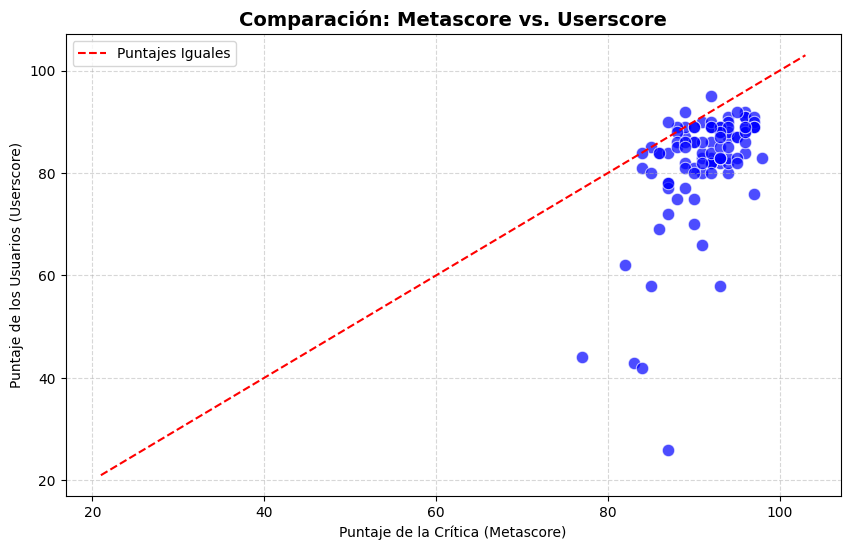

In [29]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='metascore', y='userscore', color='blue', alpha=0.7, s=80)

minimo = min(df['metascore'].min(), df['userscore'].min()) - 5
maximo = max(df['metascore'].max(), df['userscore'].max()) + 5
plt.plot([minimo, maximo], [minimo, maximo], color='red', linestyle='--', label='Puntajes Iguales')

plt.title('Comparación: Metascore vs. Userscore', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de la Crítica (Metascore)')
plt.ylabel('Puntaje de los Usuarios (Userscore)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Casi todos los elementos están por debajo de la línea roja, lo que nos indican que los críticos casi siempre puntúan los juegos con puntajes más altos que los usuarios, hipótesis que ya veníamos planteando anteriormente. Los puntos en su gran mayoría se concentran entre [85, 95] para "metascore" y [80, 90] para "userscore". El resto de elementos están dispersos y alejados de esa especie de cluster, y en su gran mayoría, se debe a casos en los que los usuarios infrapuntúan los juegos, como exagerando lo malos que son. Estos puntajes son posibles anomalías, y provienen de los puntajes de los usuarios principalmente. Más adelante compararemos "userscore" con "userscore_count" para analizar esas anomalías, y ver si de verdad es el juego tan malo o fueron unos pocos usuarios los que jugaron y puntuaron muy mal el juego.
<br>
<br>

Respecto a la relación entre ambos atributos, podemos observar una correlación positiva entre ellos: cuando "metascore" es alto, "userscore" suele ser alto también. Lo que no coinciden es en el nivel de puntaje, los usuarios suelen infrapuntuar los juegos respecto a los críticos.

#### Instancia 2.3.2: Análisis de relación entre "genres" y "userscore"

La idea es analizar cómo influye el género de un videojuego en el puntaje del mismo de los usuarios "userscore". Utilizaremos boxplots ya que permiten resumir estadísticamente demasiado bien atributos numéricos como "userscore", y podemos hacer un boxplot por cada género y comparar los boxplots directamente.

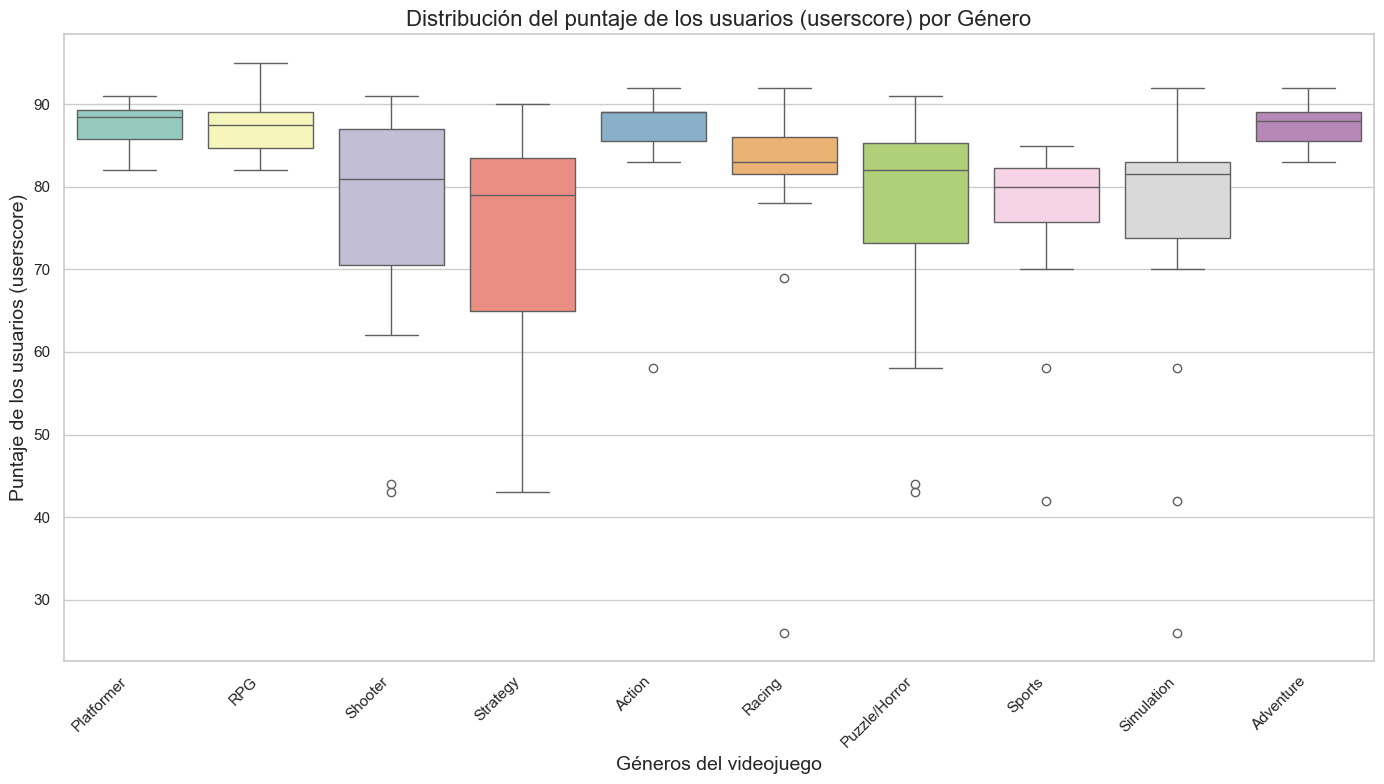

In [30]:
df_genres = df.copy()
df_genres["genres"] = df_genres["genres"].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)
df_genres = df_genres.explode("genres")

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df_genres, x="genres", y="userscore", hue="genres", palette="Set3", legend=False)

plt.title("Distribución del puntaje de los usuarios (userscore) por Género", fontsize=16)
plt.xlabel("Géneros del videojuego", fontsize=14)
plt.ylabel("Puntaje de los usuarios (userscore)", fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

A partir del boxplot podemos hacer varias observaciones:
* Géneros mejores puntuados: Los juegos de los géneros Platformer, RPG, Action, Adventure y Racing presentan las puntuaciones más altas y estables. El boxplot y las astas son pequeños, los puntajes presentan baja diserpsión, por eso decimos que es estable. Además, el boxplot se encuentra en la parte superior de las puntuaciones, por eso decimos que los puntajes son altos. A pesar de esto, hay 2 juegos de género Racing y 1 juego de género Action que presentan bajo puntaje de los usuarios respecto a los demás juegos de esa clasificación. Esos 3 juegos constituirían posibles anomalías en el puntaje.
* Géneros peores puntuados: Los juegos de los géneros Shooter, Strategy y Puzzle/Horror tienen boxplots más grandes, lo que indica que las puntuaciones que los usuarios les asignan difieren más entre sí, el "userscore" es más disperso. Además, presentan puntuaciones un poco más bajas, teniendo una mediana más cercana a 80 (mientras que Platformer, RPG y ese grupo tenían una mediana más cercana a 90).
* Géneros de puntaje intermedio: Los juegos de género Simulation y Sports presentan boxplots de tamaño moderado y puntaje entre 75 y 83 aproximadamente.
* En casi todos los boxplots se cumple que la mediana está más cerca de la parte superior de la caja que de la parte inferior, lo que cumple con la distribución asimétrica negativa que detectamos en la actividad 2.2 (descripción de los datos). La excepción a esto es el género Racing.


#### Instancia 2.3.3: Análisis de relación entre "userscore" y "userscore_count"

Anteriormente habíamos notado que había solo unos pocos juegos que alcanzaban puntuaciones muy bajas con respecto a la mayoría de juegos. Queremos ver si se trataba de anomalías o no, y una de las causas de estas anomalías podían ser unos pocos usuarios puntuandolos muy bajo a esos juegos y sesgando la puntuación. Para ello, compararemos la cantidad de usuarios que puntuaron el juego con el puntaje obtenido. Tomaremos los 10 juegos mejor puntuados, 10 juegos de puntaje promedio y los 10 juegos peores puntuados, para comparar el volumen de usuarios que puntuaron esos juegos y ver si algo tiene que ver con estas desviaciones del comportamiento normal.
<br>
<br>

Para esta representación utilizamos un gráfico de barras horizontales. Es como un diagrama de postes horizontal, los postes horizontales o barras representan el volumen de votantes. De todas maneras, incluimos la cantidad de usuarios que puntuaron al lado del juego porque cuando la barra es muy pequeña no se alcanza a distinguir bien cuántos puntuaron. Junto a la barra incluimos también el nombre del juego y el puntaje que obtuvo.

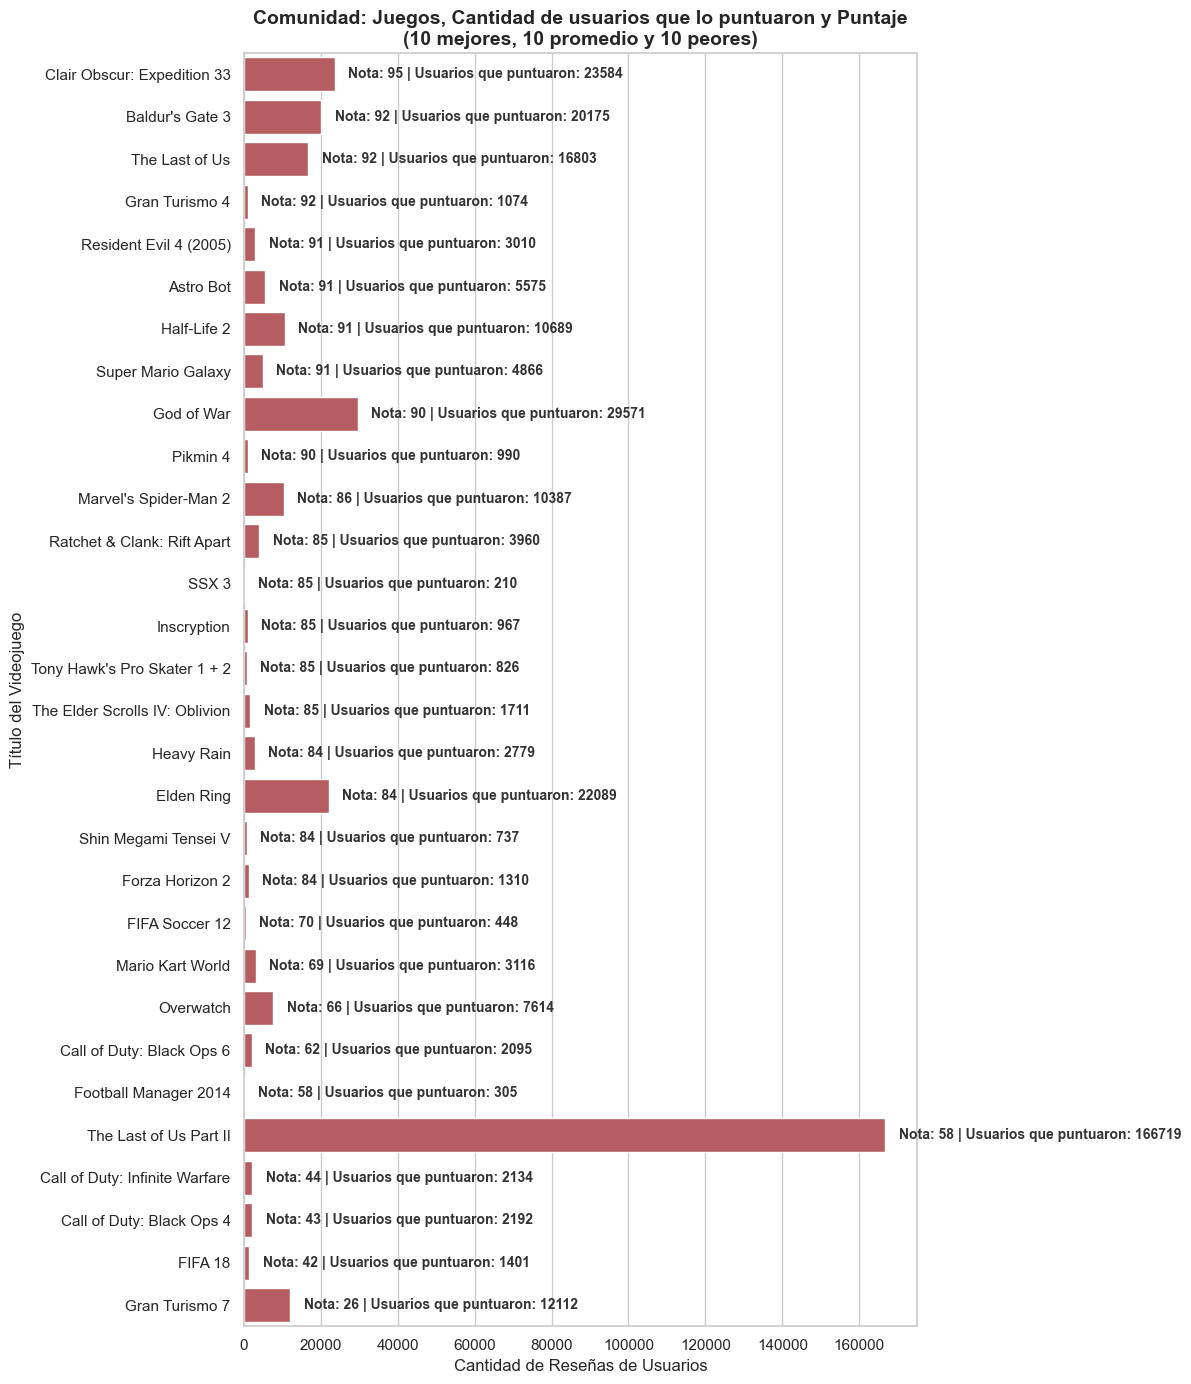

In [50]:
# Ordenar por userscore
df_ordenado = df.sort_values("userscore").reset_index(drop=True)

# Los 10 juegos peores puntuados
df_peores = df_ordenado.head(10)

# Los 10 juegos mejor puntuados
df_mejores = df_ordenado.tail(10)

# Los 10 juegos con puntaje promedio
medio = len(df_ordenado) // 2
df_promedio = df_ordenado.iloc[medio - 5 : medio + 5]

# Unir los 3 dfs de los 10 mejores, peores y promedios
df_muestra = pd.concat([df_mejores, df_promedio, df_peores])
df_muestra = df_muestra.sort_values("userscore", ascending=False)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 14))

sns.barplot(
    data=df_muestra,
    x="userscore_count",
    y="title",
    ax=ax,
    color="#C44E52"
)

ax.set_title("Comunidad: Juegos, Cantidad de usuarios que lo puntuaron y Puntaje\n(10 mejores, 10 promedio y 10 peores)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de Reseñas de Usuarios", fontsize=12)
ax.set_ylabel("Título del Videojuego", fontsize=12)

# TEXTO AL LADO DE CADA BARRA
for i, (count, score) in enumerate(zip(df_muestra["userscore_count"], df_muestra["userscore"])):
    margen = ax.get_xlim()[1] * 0.02
    ax.text(count + margen, i,
            f"Nota: {score} | Usuarios que puntuaron: {count}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#333333")

plt.tight_layout()
plt.show()

Podemos observar que los valores más bajos y altos de "userscore" encontrados en el dataset no se trata de unos pocos usuarios que los puntuaron muy mal o muy bien, sino que fueron más de 1000 usuarios los que consideraron a ese juego muy bueno o muy malo. Esto nos da cierta base sólida de que en verdad ese juego era muy malo o muy bueno para la comunidad, por lo que podemos confiar en ese "userscore". Hasta podemos afirmar que esos puntajes extremos tienen una base sólida de usuarios que los respaldan, como en el caso de Gran Turismo 7, un juego muy puntuado por los usuarios pero que registra una puntuación increíblemente baja (puntuación 26, usuarios que puntuaron: 12112). Sucede lo mismo para los 3 juegos de mayor puntuación, con puntajes promedio que alcanzan los 95 puntos realizados por más de 10000 usuarios. En cualquier caso, los puntajes extremos no son una anomalía sesgada por unos pocos usuarios, sino producto de un juego realmente aclamado/detestado por la comunidad.
<br>
<br>

Y para complementar este análisis realizaremos un histograma que represente la cantidad total de usuarios que puntuaron juegos en función de intervalos de "userscore". Partimos el dataset de juegos en 10 intervalos con igual cantidad de juegos según los puntajes en "userscore", con el fin de visualizar mejor si juegos con mayor/menor puntaje tienden a tener más/menos puntuaciones de usuarios.

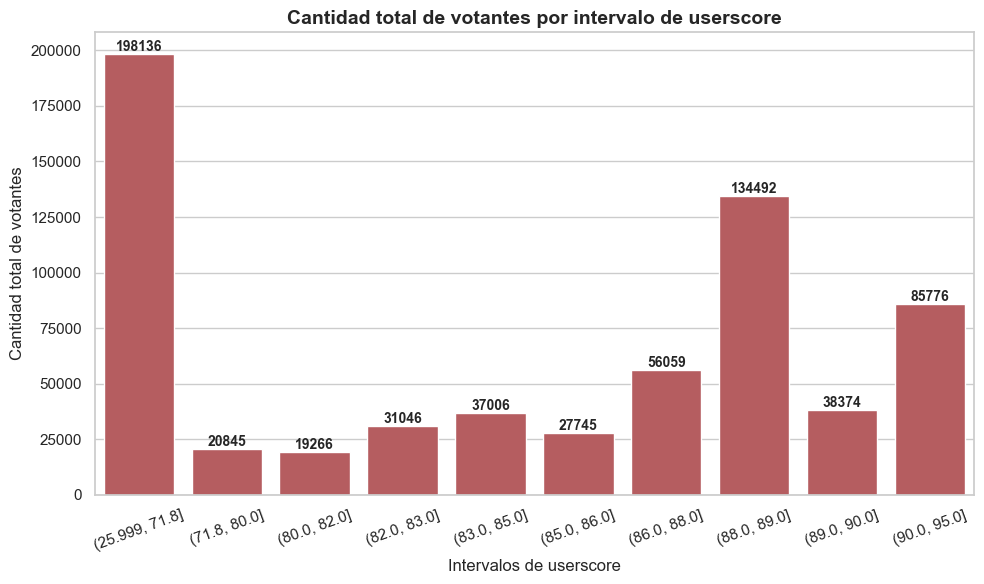

In [51]:
# Nos quedamos solo con las columnas necesarias y quitamos nulos
df_aux = df[["userscore", "userscore_count", "title"]].dropna().copy()

# Crear 10 intervalos con igual cantidad de juegos según userscore
df_aux["intervalo_userscore"] = pd.qcut(df_aux["userscore"], q=10)

# Sumar la cantidad total de votantes por intervalo
df_intervalos = (
    df_aux
    .groupby("intervalo_userscore", observed=False)["userscore_count"]
    .sum()
    .reset_index()
)

# Pasar el intervalo a texto para que se vea bien en el gráfico
df_intervalos["intervalo_userscore"] = df_intervalos["intervalo_userscore"].astype(str)

# Gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_intervalos,
    x="intervalo_userscore",
    y="userscore_count",
    color="#C44E52"
)

plt.title("Cantidad total de votantes por intervalo de userscore", fontsize=14, fontweight="bold")
plt.xlabel("Intervalos de userscore", fontsize=12)
plt.ylabel("Cantidad total de votantes", fontsize=12)
plt.xticks(rotation=20)

# Etiquetas arriba de cada barra
for i, total in enumerate(df_intervalos["userscore_count"]):
    ax.text(i, total, f"{int(total)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

Conclusiones:
* Vemos que los juegos con "userscore" extremos, tanto altos como bajos, tienden a tener mayor cantidad de usuarios. Pueden ser juegos muy esperados que salieron y decepcionaron, por lo que terminan con muchos usuarios que lo puntúan bajo, o un juego popular y ampliamente aceptado por los usuarios.  
* El primer intervalo está distorsionado por el juego The Last of Us Part II, que cómo observamos anteriormente tiene aproximadamente 160000 usuarios que lo puntuaron, un valor muy superior al resto de videojuegos. Si se excluyera este juego del análisis, el intervalo sería similar a la de los intervalos intermedios.
* En el último intervalo, correspondiente a los mayores valores de "userscore", sin embargo, hay como 5 juegos que presentan una cantidad considerable de usuarios, alrededor de 20000 votantes, lo que refuerza la idea de que los juegos mejor votados concentran una gran cantidad de puntuaciones.
* En general, los intervalos intermedios presentan cantidades de usuarios relativamente similares entre sí, con aglunas variaciones puntuales como la del intervalo [88, 89], posiblemente distorsionada por la presencia de algún juego muy popular.
* En conjunto, considerando el juego "The Last of Us" un outlier, los juegos que concentran mayores cantidades de jugadores o con mayor cantidad de usuarios que los puntuaron, tienden a tener puntuaciones más altas, aunque no es un indicador super fiable de alto puntaje.

#### Instancia 2.3.4: Análisis de relación entre "genres" y "platforms"

Para realizar este análisis, vamos a enfocarnos en las principales plataformas:
* PC.
* Xbox (incluye Xbox 360, Xbox One, Xbox Series X y Xbox).
* PlayStations (incluye PlayStation 3, PlayStation 4, PlayStation 5, PlayStation 2 y PlayStation).
* Nintendo Switch (incluye Nintendo Switch y Nintendo Switch 2).
<br>
<br>

Agruparemos los juegos en estas 4 categorías y no consideraremos las otras plataformas ya que son demasiadas plataformas que contienen pocos juegos y molestan en la visualización de lo importante.
<br>
<br>

Lo que queremos visualizar es la cantidad de juegos de c/género presentes por plataforma. Y para ello utilizaremos un mapa de calor, en el que cada celda tendrá un valor y color asignado. El valor será la cantidad de juegos de ese género que hay en esa plataforma, y la intensidad del color representará qué tan grande es ese valor. Además, queremos saber cuántos juegos hay por categoría de plataforma, así que ese análisis también lo incluimos en el código.

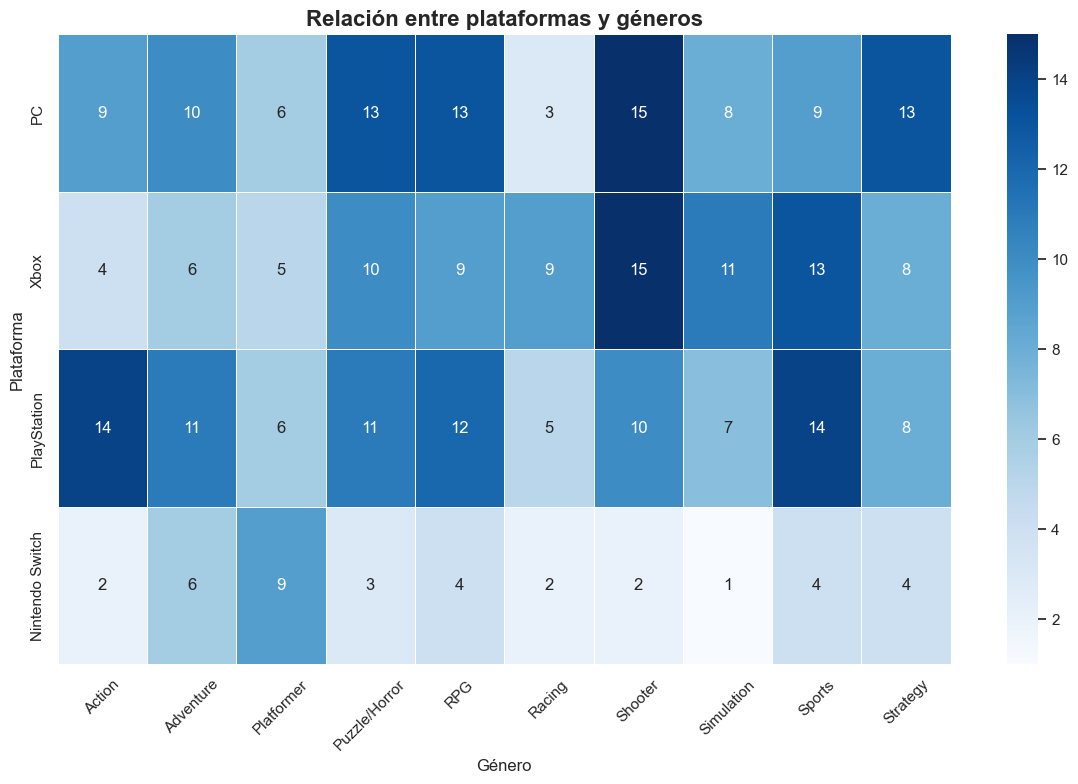

Cantidad de juegos por plataforma:
PC: 57 juegos
Xbox: 55 juegos
PlayStation: 60 juegos
Nintendo Switch: 25 juegos


In [66]:
# Separar géneros
df_gen = df.assign(genero=df['genres'].str.split(',')).explode('genero')
df_gen['genero'] = df_gen['genero'].str.strip()

# Separar plataformas
df_plat_gen = df_gen.assign(plataforma=df_gen['platforms'].str.split(',')).explode('plataforma')
df_plat_gen['plataforma'] = df_plat_gen['plataforma'].str.strip()

# Agrupar plataformas en 4 categorías principales
mapeo_plataformas = {
    'PC': 'PC',

    'Xbox': 'Xbox',
    'Xbox 360': 'Xbox',
    'Xbox One': 'Xbox',
    'Xbox Series X': 'Xbox',

    'PlayStation': 'PlayStation',
    'PlayStation 2': 'PlayStation',
    'PlayStation 3': 'PlayStation',
    'PlayStation 4': 'PlayStation',
    'PlayStation 5': 'PlayStation',

    'Nintendo Switch': 'Nintendo Switch',
    'Nintendo Switch 2': 'Nintendo Switch'
}

# Crear columna agrupada
df_plat_gen['plataforma_grupo'] = df_plat_gen['plataforma'].map(mapeo_plataformas)

# Eliminar plataformas que no pertenecen a esas 4 categorías
df_plat_gen = df_plat_gen.dropna(subset=['plataforma_grupo'])

# Evitar doble conteo del mismo juego en la misma plataforma agrupada y género
df_plat_gen = df_plat_gen.drop_duplicates(subset=['title', 'plataforma_grupo', 'genero'])

# Resetear índice
df_plat_gen = df_plat_gen.reset_index(drop=True)

# Tabla cruzada
tabla_cruzada = pd.crosstab(df_plat_gen['plataforma_grupo'], df_plat_gen['genero'])

# Ordenar filas
orden_plataformas = ['PC', 'Xbox', 'PlayStation', 'Nintendo Switch']
tabla_cruzada = tabla_cruzada.reindex(orden_plataformas)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_cruzada, annot=True, cmap='Blues', fmt='d', linewidths=.5)

plt.title('Relación entre plataformas y géneros', fontsize=16, fontweight='bold')
plt.ylabel('Plataforma', fontsize=12)
plt.xlabel('Género', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Cantidad de juegos únicos por plataforma
juegos_por_plataforma = (
    df_plat_gen
    .groupby('plataforma_grupo')['title']
    .nunique()
    .reindex(orden_plataformas)
)

print("Cantidad de juegos por plataforma:")
for plataforma, cantidad in juegos_por_plataforma.items():
    print(f"{plataforma}: {cantidad} juegos")

Conclusiones:
* La primera observación es que las plataformas PC, Xbox y PlayStation están mucho más parejas de lo que pensabamos inicialmente, teniendo aproximadamente la misma cantidad de juegos (entre 55 y 60).
* Nintendo Switch domina en los juegos del género Platformer, lo cuál tiene sentido ya que Nintendo se especializa en juegos de plataforma. Lo que le da más fuerza a este valor es que Nintendo tiene pocos juegos comparados a las otras plataformas y sin embargo sigue dominando el género. En el resto de géneros, Nintendo Switch prácticamente no aparece.
* Xbox y PC dominan los juegos del género Shooter. Ambas plataformas están muy asociadas a éste género, estos valores tienen sentido.
* Más allá de estas observaciones, podemos ver más cosas, como la dominancia de PlayStation en los juegos del género Action, o la tendencia de Xbox de dominar los juegos de género Racing. Pero también tenemos que tener en cuenta que estamos hablando de cantidades bajas de juegos, y las conclusiones que realicemos pueden estar sesgadas por cuestiones probabilísticas. Si calcularamos el intervalo de confianza que obtenemos de tomar 100 juegos y asignarle géneros y plataformas a c/uno, por más que PlayStation tenga más probabilidades de tener juegos Shooter (por decir un ejemplo), hay bastantes probabilidades de que justo se seleccionen juegos Shooter de la plataforma Xbox y parezca que la tendencia es que Xbox tenga juegos de género Shooter, cuando no es así. Necesitaríamos más juegos para asegurar que estas correspondencias son reales.

### Actividad 2.4: Verificación de la calidad de los datos

#### Instancia 2.4.1: Análisis de valores nulos
Recapitulando, teníamos 5 valores nulos en el atributo "rating". Los nulos pueden tener varias explicaciones lógicas. Pueden ser porque:
<br>
<br>

* El juego es apto para todo público y no se especificó porque no tiene restricciones.
* El juego no fue clasificado por ESRB.
* El juego si tiene clasificación pero el dataset no la registró porque la clasificación se realizó hace poco y el juego se cargó hace mucho en el dataset.



## Fase 3 - Preparación de los datos

Se procede a disminuir las columnas del data frame, asi poseemos un data frame util (dfu) con el cual trabajar con comodidad. Las columnas que dejaremos seran las siguientes: id, title, genres, description, platforms, metascore, userscore

**Transformación de variables categóricas: One-Hot Encoding**

El atributo "genres" presenta una estructura multivaluada, ya que cada juego puede pertenecer a múltiples géneros al mismo tiempo. Para el modelo, necesitamos una variable numérica.

Para resolver este problema, se aplicó la técnica de codificación **One-Hot Encoding**, la cual transforma cada categoría posible en una variable binaria independiente. Entonces, se genera una nueva columna por cada género, donde el valor es 1 si el juego pertenece a dicho género y 0 en caso contrario.

In [18]:
dfu = df[['id', 'title', 'genres', 'description', 'platforms', 'metascore', 'userscore']]

dfu['genres_limpios'] = dfu['genres'].apply(lambda x: '|'.join([g.strip() for g in x.split(',')]))

columnas_generos = dfu['genres_limpios'].str.get_dummies(sep='|')

genre_mapping = {
    'Action': 'action',
    'Adventure': 'adventure',
    'Platformer': 'platformer',
    'Puzzle/Horror': 'puzzle_horror',
    'RPG': 'rpg',
    'Racing': 'racing',
    'Shooter': 'shooter',
    'Simulation': 'simulation',
    'Sports': 'sports',
    'Strategy': 'strategy'
}

columnas_generos = columnas_generos.rename(columns=genre_mapping)

for genero in genre_mapping.values():
    if genero not in columnas_generos.columns:
        columnas_generos[genero] = 0

dfu = pd.concat([dfu, columnas_generos[list(genre_mapping.values())]], axis=1)

dfu = dfu.drop(columns=['genres', 'genres_limpios'])

dfu.head()

,id,title,description,platforms,metascore,userscore,action,adventure,platformer,puzzle_horror,rpg,racing,shooter,simulation,sports,strategy
0,1300638463,Astro Bot,When the PS5 mothership is attacked by ASTRO’s...,PlayStation 5,94.0,91,0,0,1,0,0,0,0,0,0,0
1,1300501848,Baldur's Gate 3,"An ancient evil has returned to Baldur's Gate,...","PC,PlayStation 5,Xbox Series X",96.0,92,0,0,0,0,1,0,0,0,0,0
2,1300044321,Battlefield 3,"As bullets whiz by, walls crumble, and explosi...","PC,Xbox 360,PlayStation 3",89.0,77,0,0,0,0,0,0,1,0,0,1
3,1300022724,BioShock,"Going beyond ""run and gun corridors,"" ""monster...","PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)",96.0,88,0,0,0,0,0,0,1,0,0,0
4,1300287014,Bloodborne,Bloodborne is an action RPG in which you hunt ...,PlayStation 4,92.0,89,1,0,0,0,1,0,0,0,0,0


Guardar en "../database/juegos.csv"

In [17]:
dfu.to_csv("../database/juegos.csv", index=False)

## Fase 4 - Modelado

### 4.1 Representación del Perfil del Usuario

Para el sistema recomendador adoptamos un enfoque **basado en contenido**, donde tanto los usuarios como los ítems son representados en un mismo espacio de características.

Siendo $k$ el número de géneros considerados en el sistema, cada usuario $u$ es representado mediante un vector de preferencias:

$$
u = (u_1, u_2, ..., u_k)
$$

donde cada componente $u_i$ toma valores en el rango $[0,10]$ y representa el grado de preferencia del usuario por el género $i$.

En nuestro caso, el espacio de características está compuesto por los siguientes géneros:

- Action
- Adventure
- Platformer
- Puzzle/Horror
- RPG
- Racing
- Shooter
- Simulation
- Sports
- Strategy

De esta forma, cada usuario registra su perfil de preferencias al momento de crear su cuenta, lo que permite **mitigar el problema de cold-start** inicial y disponer de una representación explícita de sus gustos desde el comienzo.

### 4.2 Representación de los Ítems

Cada ítem se representa en el mismo espacio de características mediante un vector binario:

$$
x = (x_1, x_2, ..., x_k)
$$

donde:

- $x_i = 1$ si el ítem pertenece al género $i$
- $x_i = 0$ en caso contrario

Esta representación permite que usuarios e ítems existan en un **mismo espacio vectorial**, facilitando posteriormente el cálculo de afinidad entre ambos.

En lugar de depender únicamente de una matriz usuario-ítem altamente dispersa, el sistema utiliza esta representación basada en características para modelar las relaciones entre usuarios y videojuegos. Esto permite realizar operaciones simples sobre vectores de dimensión reducida para estimar similitud, preferencia y compatibilidad entre usuarios e ítems.

La información de las características de los ítems se obtiene a partir del dataset de videojuegos procesado durante la etapa de preparación de datos.

### 4.3 Modelado de las Interacciones y Feedback Explícito

El sistema incorpora **feedback explícito**, permitiendo que los usuarios asignen un ranking discreto a los ítems con los que interactúan.

El ranking posible se define como:

$$
r \in \{1,2,3,4,5\}
$$

Cada interacción se registra como una tupla:

$$
(userId, itemId, ranking)
$$

Estas interacciones se almacenan persistentemente en el sistema y permiten mantener un historial del comportamiento del usuario.

Este mecanismo constituye la base para el aprendizaje incremental del perfil del usuario, ya que cada nueva interacción se utiliza para ajustar las preferencias registradas previamente. Además, estas valoraciones alimentan el componente colaborativo del recomendador, permitiendo aprovechar también información proveniente de otros usuarios.

### 4.4 Actualización Incremental del Perfil del Usuario

Para incorporar aprendizaje dinámico en el sistema, el perfil del usuario se actualiza después de cada interacción utilizando un esquema de **relevance feedback lineal**.

La actualización del perfil se define como:

$$
u_{new} = u_{old} + \alpha \cdot f(r) \cdot x
$$

donde:

- $\alpha$ es el peso de la transformación
- $f(r)$ es una función que transforma el ranking en un peso numérico
- $x$ es el vector de características del ítem evaluado

Los valores utilizados en el sistema son los siguientes:

$$
\alpha = 1
$$

Cabe aclarar que $\alpha$ podría utilizarse como un factor de aprendizaje variable. Sin embargo, por simplicidad y para facilitar la interpretación del modelo, en este trabajo se mantiene constante.

La función de transformación del ranking es la siguiente:

- $f(1) = -1.00$
- $f(2) = -0.50$
- $f(3) = 0.00$
- $f(4) = 0.75$
- $f(5) = 1.00$

La actualización por cada género $i$ se define como:

$$
u_i = clamp(u_i + \alpha \cdot f(r) \cdot x_i)
$$

donde:

- $x_i \in \{0,1\}$ indica si el ítem pertenece al género $i$
- `clamp()` limita el valor al rango $[0,10]$

De esta manera, una valoración positiva incrementa las preferencias asociadas a los géneros del videojuego, mientras que una valoración negativa las reduce. Estos parámetros están centralizados en el archivo `config.py`.

### 4.5 Sistema Recomendador

#### 4.5.1 Selección de la técnica

Para la construcción del sistema recomendador se evalúan las siguientes estrategias:

- **Filtrado colaborativo**: recomienda ítems a partir de similitudes entre usuarios o entre ítems según interacciones históricas.
- **Filtrado basado en contenido**: recomienda ítems en función de la similitud entre las características del ítem y el perfil de preferencias del usuario.

Se propone un **enfoque híbrido**, que combina ambas estrategias.

La elección de este enfoque se fundamenta en que el sistema puede obtener información de dos fuentes complementarias.

Por un lado, se dispone de una representación explícita del perfil de cada usuario mediante preferencias sobre distintos géneros de videojuegos, así como de una representación de los ítems basada en esos mismos atributos. Esto permite aplicar técnicas de filtrado basado en contenido.

A su vez, el sistema registra las interacciones usuario–ítem a través de las valoraciones almacenadas. Estas interacciones constituyen la base para la construcción de un modelo de filtrado colaborativo, que permite capturar patrones de comportamiento colectivo y relaciones entre usuarios e ítems.

Adicionalmente, el sistema incorpora un **componente de serendipia**, cuyo objetivo es favorecer la aparición de recomendaciones inesperadas pero potencialmente valiosas para el usuario. Este componente resulta importante para evitar que el recomendador se limite a sugerir únicamente ítems muy similares a los ya consumidos, ampliando así la exploración del catálogo.

Finalmente, se incorpora una señal global de calidad del videojuego a partir de su `userscore`, utilizada como un pequeño ajuste adicional sobre el puntaje final.

En la etapa actual del proyecto, el componente basado en contenido tiene un rol predominante, ya que permite mitigar el problema de cold-start y generar recomendaciones desde el inicio. Sin embargo, a medida que el sistema crece y aumenta el volumen de interacciones registradas, el componente colaborativo adquiere mayor relevancia.

De esta manera, el sistema se concibe desde su diseño como un recomendador híbrido, donde las recomendaciones resultan de la combinación de información basada en contenido, comportamiento colectivo y un criterio adicional orientado a promover serendipia, permitiendo aprovechar las ventajas de los distintos enfoques.

#### 4.5.2 Combinación de puntajes

Una vez definidos los componentes principales del sistema recomendador, la generación de la recomendación final puede expresarse como una combinación de cuatro criterios:

- el puntaje basado en contenido,
- el puntaje basado en filtrado colaborativo,
- un puntaje adicional orientado a favorecer la serendipia,
- y un puntaje global del videojuego basado en `userscore`.

En primer lugar, se calcula un puntaje base híbrido:

$$
score_{base}(u, i) = \alpha \cdot score_{contenido}(u, i) + (1-\alpha) \cdot score_{colaborativo}(u, i)
$$

donde:

- $score_{contenido}(u, i)$ representa la afinidad entre el vector de preferencias del usuario $u$ y el vector de características del videojuego $i$.
- $score_{colaborativo}(u, i)$ representa el aporte de las valoraciones de otros usuarios sobre el videojuego $i$.
- $\alpha \in [0,1]$ regula la contribución relativa de ambos componentes.

En el sistema implementado se utiliza un valor:

$$
\alpha = 0.7
$$

lo que implica que, en esta etapa, el componente basado en contenido tiene mayor peso que el colaborativo.

A continuación, se calcula un puntaje de serendipia:

$$
score_{serendipia}(u, i)
$$

que busca priorizar videojuegos que, sin ser necesariamente los más obvios para el usuario, sigan resultando plausibles y atractivos. Este puntaje se construye a partir de una afinidad intermedia respecto del perfil del usuario, complementada por una señal suave de calidad basada en `userscore`.

Finalmente, el puntaje total de recomendación se define como:

$$
score_{intermedio}(u, i) = (1-\beta)\cdot score_{base}(u, i) + \beta \cdot score_{serendipia}(u, i)
$$

donde $\beta \in [0,1]$ es el parámetro que regula el peso relativo de la serendipia en la recomendación.

En la implementación actual se utiliza:

$$
\beta = 0.15
$$

Luego se incorpora un ajuste adicional asociado al score global del juego:

$$
score_{final}(u, i) = (1-\gamma)\cdot score_{intermedio}(u, i) + \gamma \cdot score_{juego}(i)
$$

donde $score_{juego}(i)$ corresponde al `userscore` normalizado del videojuego y $\gamma \in [0,1]$ regula cuánto influye esta señal global.

En la implementación actual se utiliza:

$$
\gamma = 0.05
$$

De esta forma, el sistema mantiene una base fuertemente apoyada en la relevancia personalizada, pero reserva una fracción controlada del puntaje para promover recomendaciones menos evidentes y para favorecer juegos con buena recepción general.

Esta arquitectura híbrida permite:

- sostener la capacidad de recomendación en situaciones de cold-start,
- incorporar información colectiva cuando se dispone de suficientes valoraciones,
- y favorecer la aparición de recomendaciones inesperadas, contribuyendo al objetivo de serendipia definido para el sistema.

#### 4.5.3 Componente colaborativo

El componente colaborativo incorpora información proveniente de las valoraciones realizadas por otros usuarios. Este componente busca aprovechar patrones de comportamiento colectivo para estimar si un videojuego puede resultar adecuado para un usuario determinado.

La idea es la siguiente: si usuarios con perfiles similares valoraron positivamente un videojuego, entonces ese videojuego debería incrementar su puntaje de recomendación. En cambio, si usuarios similares lo valoraron negativamente, su puntaje debería disminuir.

Para implementar este componente se definieron tres pasos: transformación del ranking, cálculo de similitud entre usuarios y agregación ponderada de las valoraciones.

Este componente participa exclusivamente en el puntaje base híbrido y representa la parte colectiva del sistema recomendador.

##### 4.5.3.1 Transformación del ranking

El sistema almacena valoraciones explícitas en una escala de 1 a 5. Para el cálculo del puntaje colaborativo queremos diferenciar entre valoraciones positivas, neutras y negativas.

Cada ranking se transforma a una señal centrada en cero mediante una función $g(r)$. De esta manera, una valoración alta aporta positivamente al score, una valoración intermedia no altera el resultado, y una valoración baja lo penaliza.

La transformación utilizada es la siguiente:

$$
g(r)=
\begin{cases}
-1 & \text{si } r=1 \\
-0.5 & \text{si } r=2 \\
0 & \text{si } r=3 \\
0.5 & \text{si } r=4 \\
1 & \text{si } r=5
\end{cases}
$$

Esto permite representar de forma explícita que una mala valoración no debe equivaler a ausencia de información, sino a una señal negativa.

##### 4.5.3.2 Similitud entre usuarios

Para ponderar adecuadamente las valoraciones de otros usuarios, es necesario estimar qué tan parecido es cada usuario respecto del usuario objetivo. En este caso, la similitud entre usuarios se calcula a partir de sus vectores de preferencias explícitas sobre los diez géneros considerados por el sistema.

Dado que cada usuario se representa mediante un vector numérico en el mismo espacio de características, una forma adecuada de medir cercanía es mediante la **similitud del coseno**. Esta métrica compara la orientación entre dos vectores y toma valores entre 0 y 1 cuando todas las componentes son no negativas.

Sean $u$ y $v$ dos usuarios representados por sus vectores de preferencias, entonces su similitud se define como:

$$
sim(u,v)=\frac{u \cdot v}{\|u\|\|v\|}
$$

Cuanto más próximo a 1 sea este valor, mayor será la similitud entre ambos perfiles. Si alguno de los vectores tiene norma nula, la similitud se define como 0 para evitar indeterminaciones.

##### 4.5.3.3 Cálculo del puntaje colaborativo

El puntaje colaborativo de un videojuego para un usuario dado puede calcularse agregando las valoraciones de otros usuarios que ya calificaron dicho videojuego.

Sea $u$ el usuario objetivo, $i$ el videojuego a evaluar, $V_i$ el conjunto de usuarios que valoraron el videojuego $i$, $sim(u,v)$ la similitud entre el usuario objetivo $u$ y otro usuario $v$, y $g(r_{v,i})$ la transformación de la valoración de $v$ sobre el videojuego $i$. Entonces:

$$
score_{colaborativo}(u,i)=
\frac{\sum_{v \in V_i} sim(u,v)\cdot g(r_{v,i})}
{\sum_{v \in V_i} |sim(u,v)|}
$$

Esta expresión puede interpretarse como un promedio ponderado de las valoraciones transformadas, donde las opiniones de usuarios más similares tienen mayor influencia.

De esta manera:

- si usuarios similares valoraron positivamente el videojuego, el puntaje colaborativo aumenta;
- si usuarios similares lo valoraron negativamente, el puntaje disminuye;
- si no existe información suficiente, el puntaje colaborativo tiende a cero.

Este componente permite incorporar evidencia colectiva al proceso de recomendación y complementar el análisis basado en contenido.

#### 4.5.4 Componente de serendipia

Uno de los objetivos del sistema recomendador es que una fracción de los ítems recomendados resulte **inesperada** para el usuario. En este contexto, la serendipia no se interpreta como aleatoriedad pura, sino como la capacidad de recomendar videojuegos que el usuario probablemente no habría elegido de forma directa, pero que aun así tienen posibilidades razonables de resultarle interesantes.

Para modelar este criterio se define un puntaje de serendipia basado en dos factores:

- **afinidad intermedia** con el perfil del usuario,
- **calidad general del juego** a partir de `userscore`.

La idea central es evitar que la serendipia se reduzca a recomendar cualquier ítem lejano al perfil del usuario. En cambio, se priorizan videojuegos que se encuentren en una zona intermedia: no tan obvios como los ítems con máxima afinidad, pero tampoco tan alejados como para perder relevancia.

En términos generales, el sistema busca que los ítems serendípicos cumplan simultáneamente dos condiciones:

1. que no sean la opción más esperable según el perfil explícito del usuario;
2. que no se alejen tanto del perfil del usuario como para perder plausibilidad.
3. que, aun siendo menos obvios, mantengan una recepcion general razonable.

##### 4.5.4.1 Cálculo del puntaje de serendipia

El puntaje de serendipia utilizado en el sistema se define como:

$$
score_{serendipia}(u,i)=
\lambda_1 \cdot score_{afinidad\_media}(u,i)
+ \lambda_2 \cdot score_{juego}(i)
$$

donde:

- $score_{afinidad\_media}(u,i)$ favorece ítems cuya similitud con el usuario se encuentra en una zona intermedia;
- $score_{juego}(i)$ corresponde al `userscore` normalizado del videojuego;
- $\lambda_1$ es el peso asignado a la afinidad intermedia;
- $\lambda_2$ es el peso asignado a la calidad global del juego.

En la implementación actual se utiliza:

$$
\lambda_1 = 0.85
\qquad
\lambda_2 = 0.15
$$

Finalmente, el resultado se acota al intervalo $[0,1]$ mediante una función `clamp()`.

##### 4.5.4.2 Afinidad intermedia

Para favorecer recomendaciones inesperadas, el sistema no prioriza los ítems con máxima afinidad de contenido, sino aquellos cuya afinidad se ubica cerca de un valor objetivo intermedio.

Sea $score_{contenido}(u,i)$ el puntaje de contenido entre el usuario $u$ y el ítem $i$. Entonces, la afinidad intermedia se calcula como:

$$
score_{afinidad\_media}(u,i)=
clamp\left(1-\frac{|score_{contenido}(u,i)-t|}{d}\right)
$$

donde:

- $t$ es el valor objetivo de afinidad,
- $d$ es la desviación permitida respecto de ese valor,
- `clamp()` restringe el resultado al intervalo $[0,1]$.

En la implementación actual se utilizan los parámetros:

$$
t = 0.35
\qquad
d = 0.15
$$

Esto permite favorecer videojuegos inesperados pero que no se alejen demasiado del perfil del usuario.

Por separado, el sistema incorpora un puntaje global del juego definido a partir de `userscore`, previamente normalizado al intervalo $[0,1]$:

$$
score_{juego}(i)=userscore(i)
$$

De esta forma, `userscore` cumple un doble rol: dentro de la serendipia funciona como filtro suave para evitar recomendaciones inesperadas de baja calidad, y en el puntaje final actua ademas como una señal global y acotada.

#### 4.5.5 Selección final de recomendaciones

Una vez calculado el puntaje final para todos los videojuegos no puntuados por el usuario, el sistema ordena los candidatos de mayor a menor puntaje y construye un conjunto de candidatos de alta calidad.

Sobre ese conjunto se aplica luego una selección aleatoria de tamaño $k$. En la implementación actual, el conjunto candidato se forma con los mejores $max(k, 2k)$ videojuegos según puntaje final.

Este procedimiento cumple dos propósitos:

- **Novedad**: se excluyen explícitamente los videojuegos ya puntuados por el usuario.
- **Diversidad y serendipia**: al no devolver siempre de forma determinista los primeros $k$ ítems del ranking, se introduce variabilidad dentro de un subconjunto de candidatos relevantes, favoreciendo la aparición de recomendaciones menos obvias.

De esta manera, la recomendación final no surge únicamente de una ordenación rígida por score, sino de una combinación entre relevancia estimada y exploración controlada del conjunto candidato.

#

## Fase 5 - Evaluación
BLA

## Fase 6 - Despliegue
BLA

## NOTAS PARA REVISAR

PARA VERIFICAR LA SERENDIPIA: Se considerarán recomendaciones esperables aquellas que coincidan con las sugerencias obtenidas mediante un modelo trivial de recomendación (por ejemplo, basado en popularidad o similitud directa con artículos consumidos previamente por ese usuario). Las recomendaciones que resulten relevantes para el usuario pero no pertenezcan a ese conjunto serán consideradas serendípicas.

PARA VERIFICAR LA RELEVANCIA: Un ítem es relevante si cumple en cierta medida con las preferencias del usuario (habría que ajustar como medimos si cumple o no)

PARA VERIFICAR LA NOVEDAD: Fijarse nomás si el ítem recomendado ya tiene rating por parte del usuario (si ya lo tiene, está mal, no cumple)

PARA VERIFICAR LA DIVERSIDAD: Mepa que hay métricas de diversidad hechas para esto, utilizaremos esta, más adelante vemos.

REVISAR SI USAMOS TODAS LAS LIBRERÍAS CARGADAS